In [1]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_curve, precision_recall_curve, roc_auc_score, auc, average_precision_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import cmcrameri.cm as cram
np.random.seed(42)

## Load healthy data

In [ ]:
healthy_data = np.load('data/RatHealthyData_preGd_fit.npz')
print(healthy_data.keys())

KeysView(<numpy.lib.npyio.NpzFile object at 0x1044f0a00>)


In [3]:
healthy_fits = healthy_data['fits']
healthy_masks = healthy_data['roimasks']
print(healthy_fits.shape)
print(healthy_masks.shape)

(4, 192, 192, 15)
(4, 192, 192)


In [4]:
n_features = healthy_fits.shape[-1]
X_train = healthy_fits.reshape(-1, n_features)
inds = healthy_masks.reshape(-1)

X_train = X_train[inds]
print(X_train.shape)

(17098, 15)


In [5]:
# remove any improperly masked voxels
nonzeroInds = np.where((np.sum(X_train, axis=1) > 0))[0]
X_train = X_train[nonzeroInds]
print(X_train.shape)

(16611, 15)


## Load tumor data

In [ ]:
tumor_data = np.load('data/RatTumorData_postGd_fit.npz')
for key in tumor_data.keys():
    print(key)

fits
roimasks
lesionMasks


In [ ]:
tumor_masks = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
for key in tumor_masks.keys():
    print(key)

zspec
voxelInds_healthy
voxelInds_tumor
imageShape


In [8]:
imShape_tumor = tumor_masks['imageShape'][:-1]
print(imShape_tumor)

[  3 192 192]


In [9]:
test_fits = tumor_data['fits']
print(test_fits.shape)

tumor_voxelInds = tumor_masks['voxelInds_tumor']
tumor_healthyInds = tumor_masks['voxelInds_healthy']

(3, 192, 192, 15)


In [10]:
voxelInds_im_tumor = np.zeros(imShape_tumor)
voxelInds_im_tumor = voxelInds_im_tumor.reshape(-1,1)
voxelInds_im_tumor[tumor_voxelInds] = 1
voxelInds_im_tumor = voxelInds_im_tumor.reshape(imShape_tumor)
print(voxelInds_im_tumor.shape)

(3, 192, 192)


In [11]:
voxelInds_im_healthy = np.zeros(imShape_tumor)
voxelInds_im_healthy = voxelInds_im_healthy.reshape(-1,1)
voxelInds_im_healthy[tumor_healthyInds] = 1
voxelInds_im_healthy = voxelInds_im_healthy.reshape(imShape_tumor)
print(voxelInds_im_healthy.shape)

(3, 192, 192)


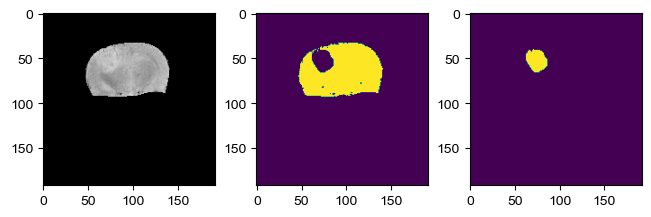

In [12]:
fig, ax = plt.subplots(1,3,layout='constrained')
ax[0].imshow(test_fits[1,:,:,0], cmap='gray', vmin=0, vmax=1)
ax[1].imshow(voxelInds_im_healthy[1,:,:])
ax[2].imshow(voxelInds_im_tumor[1,:,:])

## Separate validation and test set from tumor data

In [13]:
from hypersearch import *

In [14]:
val_data = test_fits[-1].reshape(-1,n_features)
val_tumor_inds = voxelInds_im_tumor[-1].reshape(-1)
val_healthy_inds = voxelInds_im_healthy[-1].reshape(-1)

In [15]:
test_data = test_fits[:-1].reshape(-1,n_features)
test_tumor_inds = voxelInds_im_tumor[:-1].reshape(-1)
test_healthy_inds = voxelInds_im_healthy[:-1].reshape(-1)

In [16]:
val_all_inds = val_tumor_inds + val_healthy_inds

X_val = val_data[val_all_inds.astype(bool)]

y_val = val_all_inds
y_val[val_tumor_inds.astype(bool)] = 2
y_val_inds = np.nonzero(y_val)[0]
y_val = y_val[y_val_inds] - 1
print(np.unique(y_val, return_counts=True))

(array([0., 1.]), array([4083,  847]))


In [17]:
test_all_inds = test_tumor_inds + test_healthy_inds

X_test = test_data[test_all_inds.astype(bool)]

y_test = test_all_inds
y_test[test_tumor_inds.astype(bool)] = 2
y_test_inds = np.nonzero(y_test)[0]
y_test = y_test[y_test_inds] - 1
print(np.unique(y_test, return_counts=True))

(array([0., 1.]), array([8672,  648]))


## Perform hyperparameter search

In [87]:
from hypersearch import *

In [88]:
iforest_param_dist = {
    "n_estimators": [50, 100, 15, 200, 250, 300, 400, 500],
    "bootstrap": [True, False]
}

results_if = randomized_search_iforest(
    iforest_param_dist,
    X_train,
    X_val,
    y_val,
    n_iter=40
)

/Users/anshumanswain/miniconda/lib/python3.10/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [89]:
results_if

[{'params': {'n_estimators': 50, 'bootstrap': True},
  'auc': 0.8067634945599008,
  'f1': 0.523335883703137,
  'threshold': -0.04016476448087376},
 {'params': {'n_estimators': 100, 'bootstrap': False},
  'auc': 0.7840931139308001,
  'f1': 0.49029475197699496,
  'threshold': -0.04783207168434739},
 {'params': {'n_estimators': 250, 'bootstrap': False},
  'auc': 0.7835119036775574,
  'f1': 0.49016223679668625,
  'threshold': -0.05287784115984752},
 {'params': {'n_estimators': 200, 'bootstrap': True},
  'auc': 0.774962618927618,
  'f1': 0.4862665310274669,
  'threshold': -0.05715650702156487},
 {'params': {'n_estimators': 400, 'bootstrap': True},
  'auc': 0.7733716642941144,
  'f1': 0.48249566724436743,
  'threshold': -0.057619463731578585},
 {'params': {'n_estimators': 500, 'bootstrap': True},
  'auc': 0.7730758542995535,
  'f1': 0.4816099930603747,
  'threshold': -0.05111279677861208},
 {'params': {'n_estimators': 250, 'bootstrap': True},
  'auc': 0.7758167955883539,
  'f1': 0.4808664259

In [90]:
lof_param_grid = {
    "n_neighbors": [10, 20, 30, 40, 50],
    "leaf_size": [20, 30, 40, 50],
    "p": [1,2]
}

results_lof = grid_search_lof(
    lof_param_grid,
    X_train,
    X_val,
    y_val
)

In [91]:
results_lof

[{'params': {'n_neighbors': 10, 'leaf_size': 20, 'p': 2},
  'auc': 0.8031354124467477,
  'f1': 0.5136821891502641,
  'threshold': -0.20722980126222013},
 {'params': {'n_neighbors': 10, 'leaf_size': 30, 'p': 2},
  'auc': 0.8031354124467477,
  'f1': 0.5136821891502641,
  'threshold': -0.20722980126222013},
 {'params': {'n_neighbors': 10, 'leaf_size': 40, 'p': 2},
  'auc': 0.8031354124467477,
  'f1': 0.5136821891502641,
  'threshold': -0.20722980126222013},
 {'params': {'n_neighbors': 10, 'leaf_size': 50, 'p': 2},
  'auc': 0.8031354124467477,
  'f1': 0.5136821891502641,
  'threshold': -0.20722980126222013},
 {'params': {'n_neighbors': 10, 'leaf_size': 20, 'p': 1},
  'auc': 0.8105543733758283,
  'f1': 0.5130278526504941,
  'threshold': -0.16446398188050032},
 {'params': {'n_neighbors': 10, 'leaf_size': 30, 'p': 1},
  'auc': 0.8105543733758283,
  'f1': 0.5130278526504941,
  'threshold': -0.16446398188050032},
 {'params': {'n_neighbors': 10, 'leaf_size': 40, 'p': 1},
  'auc': 0.8105543733758

In [92]:
if_thresh = results_if[0]['threshold']
lof_thresh = results_lof[0]['threshold']

## Test Isolation Forest and LOF

In [93]:
metrics = { 'IF': {'Accuracy': [],
                    'F1_score': [],
                    'FPR': [],
                    'TPR': [],
                    'ROC-AUC': []},
            'LOF': {'Accuracy': [],
                    'F1_score': [],
                    'FPR': [],
                    'TPR': [],
                    'ROC-AUC': [],
                    'Precision': [],
                    'Recall': [],
                    'PR-AUC': []}}

In [94]:
if_clf = IsolationForest(n_estimators=50, bootstrap=True, n_jobs=-1)
if_clf.fit(X_train)

if_scores = if_clf.decision_function(X_test)

if_predictions = (-if_scores >= if_thresh).astype(int) 
print(np.unique(if_predictions, return_counts=True))

(array([0, 1]), array([6111, 3209]))


In [95]:
lof_clf = LocalOutlierFactor(novelty=True)
lof_clf.fit(X_train)

lof_scores = lof_clf.decision_function(X_test)

lof_predictions = (-lof_scores >= lof_thresh).astype(int)
print(np.unique(lof_predictions, return_counts=True))

(array([0, 1]), array([7023, 2297]))


In [96]:
predictions = [if_predictions,lof_predictions]
scores = [if_scores, lof_scores]
thresholds = [if_thresh, lof_thresh]
for key, prediction, score, thresh in zip(metrics.keys(), predictions, scores, thresholds):
    metrics[key]['Accuracy'] = accuracy_score(y_test, prediction)
    metrics[key]['F1_score'] = f1_score(y_test, prediction)
    
    metrics[key]['FPR'], metrics[key]['TPR'], roc_thresholds =  roc_curve(y_test, -score)
    
    # Find closest ROC threshold
    metrics[key]['F1_idx'] = (np.abs(roc_thresholds - thresh)).argmin()
    metrics[key]['ROC-AUC'] = auc(metrics[key]['FPR'], metrics[key]['TPR'])

    metrics[key]['Precision'] = precision_score(y_test, prediction)
    metrics[key]['Recall'] = recall_score(y_test, prediction)
    metrics[key]['Precision_vals'], metrics[key]['Recall_vals'], _ = precision_recall_curve(y_test, -score)
    metrics[key]['PR-AUC'] = auc(metrics[key]['Recall_vals'], metrics[key]['Precision_vals'])
    metrics[key]['AP'] = average_precision_score(y_test, -score)

In [97]:
_, counts = np.unique(y_test, return_counts=True)
counts

array([8672,  648])

In [101]:
metrics['LOF']

{'Accuracy': 0.7752145922746781,
 'F1_score': 0.28862478777589134,
 'FPR': array([0.00000000e+00, 1.15313653e-04, 5.76568266e-04, ...,
        9.88007380e-01, 9.88238007e-01, 1.00000000e+00]),
 'TPR': array([0., 0., 0., ..., 1., 1., 1.]),
 'ROC-AUC': 0.7970178963942418,
 'Precision': 0.1850239442751415,
 'Recall': 0.6558641975308642,
 'PR-AUC': 0.18242857256584097,
 'F1_idx': 692,
 'Precision_vals': array([0.0695279 , 0.06953536, 0.06954282, ..., 0.        , 0.        ,
        1.        ]),
 'Recall_vals': array([1., 1., 1., ..., 0., 0., 0.]),
 'AP': 0.18313289999065402}

In [ ]:
np.savez_compressed('data/FitMetrics_Params_OptimThresh.npz', **metrics)

In [99]:
if_idx = metrics['IF']['F1_idx']
lof_idx = metrics['LOF']['F1_idx']

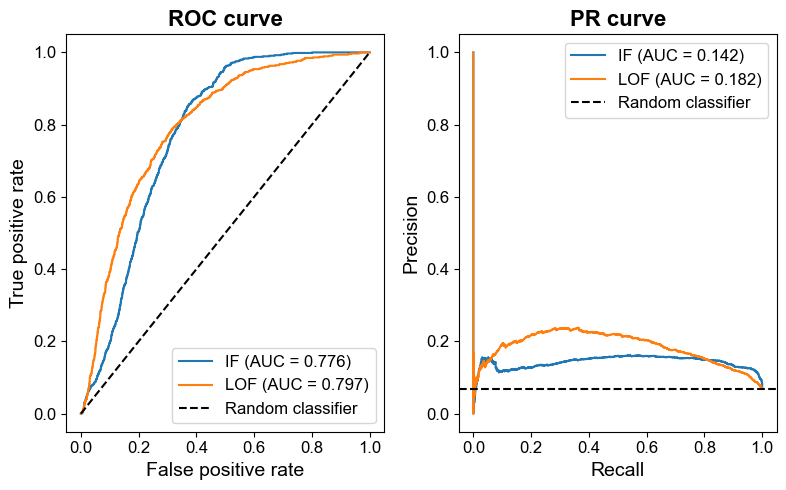

In [100]:
fig, ax = plt.subplots(1,2, figsize = (8,5))

ax[0].plot(metrics['IF']['FPR'], metrics['IF']['TPR'], label='IF (AUC = %0.3f)' % metrics['IF']['ROC-AUC'])
ax[0].plot(metrics['LOF']['FPR'], metrics['LOF']['TPR'], label='LOF (AUC = %0.3f)' % metrics['LOF']['ROC-AUC'])
# ax[0].scatter(metrics['IF']['FPR'][if_idx], metrics['IF']['TPR'][if_idx], color="red", zorder=5, alpha = 0.5)
# ax[0].scatter(metrics['LOF']['FPR'][lof_idx], metrics['LOF']['TPR'][lof_idx], color="red", zorder=5, alpha = 0.5)
ax[0].plot([0,1],[0,1],'k--', label='Random classifier')
ax[0].legend(fontsize=12)

ax[0].set_xlabel('False positive rate', fontsize=14)
ax[0].set_ylabel('True positive rate', fontsize=14)
ax[0].set_title('ROC curve', fontweight='bold', fontsize=16)

ax[1].plot(metrics['IF']['Recall_vals'], metrics['IF']['Precision_vals'], label='IF (AUC = %0.3f)' % metrics['IF']['PR-AUC'])
ax[1].plot(metrics['LOF']['Recall_vals'], metrics['LOF']['Precision_vals'], label='LOF (AUC = %0.3f)' % metrics['LOF']['PR-AUC'])
ax[1].axhline(y = counts[1] / np.sum(counts), color='k', linestyle='--', label='Random classifier')
ax[1].legend(fontsize=12)


ax[1].set_xlabel('Recall', fontsize=14)
ax[1].set_ylabel('Precision', fontsize=14)
ax[1].set_title('PR curve', fontweight='bold', fontsize=16)

for axes in ax:
    axes.tick_params(axis='both', labelsize=12)


plt.tight_layout()

In [61]:
print(metrics['IF']['Accuracy'])
print(metrics['IF']['F1_score'])

print(metrics['LOF']['Accuracy'])
print(metrics['LOF']['F1_score'])

0.6919527896995709
0.2556390977443609
0.7752145922746781
0.28862478777589134


## Plot anomaly score maps

In [63]:
anoIms_if = np.zeros([2,192,192])
anoIms_lof = anoIms_if.copy()

In [64]:
anoIms_if = anoIms_if.reshape(-1)
anoIms_if[y_test_inds] = -if_scores
anoIms_if = anoIms_if.reshape([2,192,192])

anoIms_lof = anoIms_lof.reshape(-1)
anoIms_lof[y_test_inds] = -lof_scores
anoIms_lof = anoIms_lof.reshape((2,192,192))

Text(0.5, 1.0, 'Local outlier factor')

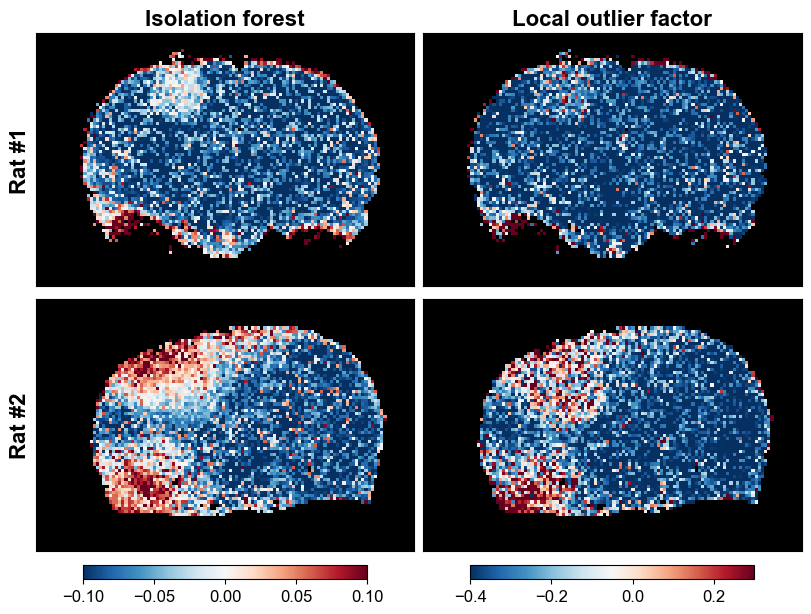

In [65]:
fig, ax = plt.subplots(2, 2, figsize=(8,6), layout='constrained')
plt.style.use('default')

# Row 1 data
im00 = anoIms_if[0,40:120,40:160]
im10 = anoIms_if[1,25:105,30:150]

# Row 2 data
im01 = anoIms_lof[0,40:120,40:160]
im11 = anoIms_lof[1,25:105,30:150]

# Mask for zeros (0 → transparent)
mask00 = im00 != 0
mask01 = im01 != 0
mask10 = im10 != 0
mask11 = im11 != 0

# --- Plot row 1 (Isolation Forest) ---
ax[0,0].set_facecolor("black")
h00 = ax[0,0].imshow(im00, cmap='RdBu_r', vmin=-0.1, vmax=0.1, alpha=mask00.astype(float))

ax[1,0].set_facecolor("black")
h01 = ax[1,0].imshow(im10, cmap='RdBu_r', vmin=-0.1, vmax=0.1, alpha=mask10.astype(float))

# Colorbar for row 1 (on the right of row)
cbar1 = fig.colorbar(h01, ax=ax[1,0], location="bottom", shrink=0.75)
cbar1.ax.tick_params(labelsize=12)

# --- Plot row 2 (LOF) ---
ax[0,1].set_facecolor("black")
h10 = ax[0,1].imshow(im01, cmap='RdBu_r', vmin=-0.4, vmax=0.3, alpha=mask01.astype(float))

ax[1,1].set_facecolor("black")
h11 = ax[1,1].imshow(im11, cmap='RdBu_r', vmin=-0.4, vmax=0.3, alpha=mask11.astype(float))

# Colorbar for row 2
cbar2 = fig.colorbar(h11, ax=ax[1,1], location="bottom", shrink=0.75)
cbar2.ax.tick_params(labelsize=12)

# Remove ticks
for axes in ax.flat:
    axes.set_xticks([])
    axes.set_yticks([])

# Labels
ax[0,0].set_ylabel('Rat #1', fontweight='bold', fontsize=16)
ax[1,0].set_ylabel("Rat #2", fontweight='bold', fontsize=16)
for a in ax.flat:
    a.tick_params(colors="white")

ax[0,0].set_title('Isolation forest', fontweight='bold', fontsize=16)
ax[0,1].set_title('Local outlier factor', fontweight='bold', fontsize=16)